This notebook serves as a sanity check as to what second-order lensing transformations do to the waveform when $R_{orbit}$ gets large.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)


import gwfast.old_lensing_utils as lutils

In [13]:
# Define a benchmark event
n = 300
shape = (n,)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.3)
}

# Vary R_orbit
events['R_orbit'] = np.linspace(20, 1000, n)

events = {key: val.astype(np.float64) for key, val in events.items()}

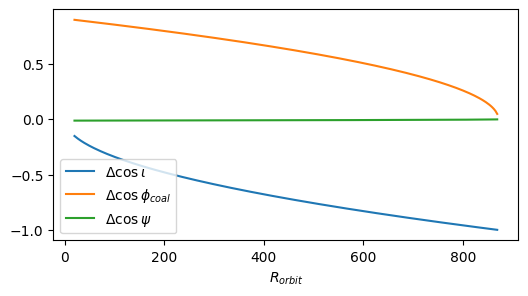

In [15]:
# Compute second order lensing corrections
# For simplicity, M_lz is used in place of M_lens
theta_E = lutils.einstein_radius(events['M_lz'], events['dL'], events['R_orbit'])
phi_L = lutils.get_phi_L(events['iota'], events['R_orbit'], events['src_pos'], theta_E, events['dL'], events['M_lz'])
delta_cos_iota, delta_cos_phi, delta_cos_psi, z_orbit, z_grav = \
    lutils.get_lensing_induced_cosine_shifts(events['iota'], phi_L, events['R_orbit'], events['phase'], events['psi'])

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot(events['R_orbit'], delta_cos_iota, label=r'$\Delta\cos\iota$')
ax.plot(events['R_orbit'], delta_cos_phi, label=r'$\Delta\cos\phi_{coal}$')
ax.plot(events['R_orbit'], delta_cos_psi, label=r'$\Delta\cos\psi$')
ax.set_xlabel(r'$R_{orbit}$')
ax.legend()

Angular shifts that are proportional to $\sin\phi_L$ approach 0 as $R_{orbit}$ gets large, while those proportional to $\cos\phi_L$ do not. Note that unfortunately the current transformations don't work for $R_{orbit}\gtrapprox 900R_S$, where the angles' cosine values get transformed out of bounds.